<a href="https://colab.research.google.com/github/PandeyChhaya/6CS012-AI-ML/blob/main/Worksheet%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Exercise 1: Color Image Processing (cameraman.png)


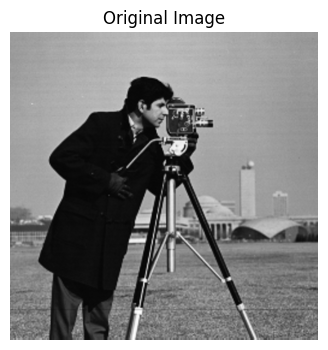

Shape: (512, 512, 3)


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Task 1: Read and display the image

img= Image.open('/content/drive/MyDrive/camera.png').convert('RGB')
img_arr = np.array(img)

plt.figure(figsize=(5,4))
plt.imshow(img_arr)
plt.title('Original Image')
plt.axis('off')
plt.show()
print(f'Shape: {img_arr.shape}')

# Task 2: Display top-left 100x100 pixels

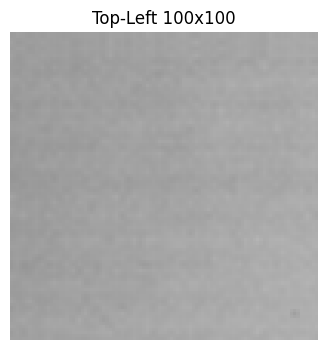

In [30]:
top_left = img_arr[:100, :100]

plt.figure(figsize=(4,4))
plt.imshow(top_left)
plt.title('Top-Left 100x100')
plt.axis('off')
plt.show()

# Task 3: Show R, G, B channels separately

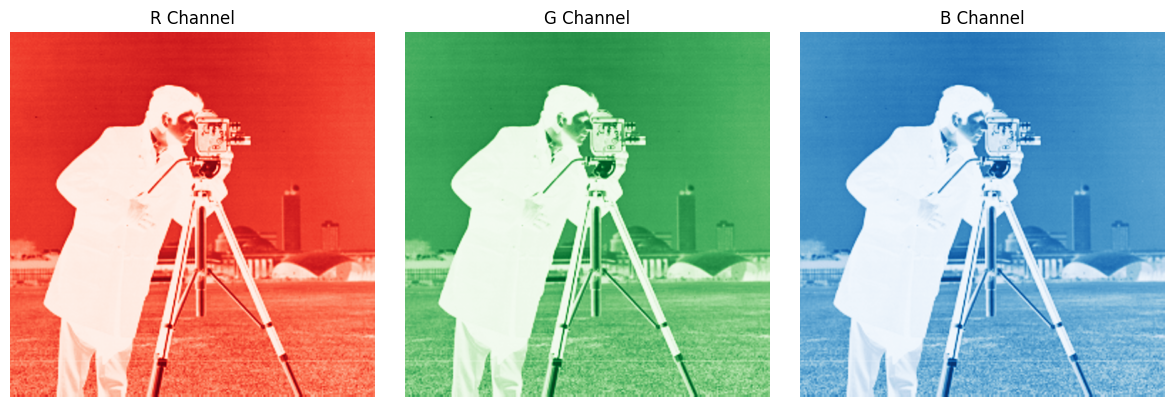

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
channels = ['R', 'G', 'B']
cmaps = ['Reds', 'Greens', 'Blues']

for i, (ch, cmap) in enumerate(zip(channels, cmaps)):
    axes[i].imshow(img_arr[:, :, i], cmap=cmap)
    axes[i].set_title(f'{ch} Channel')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Task 4: Modify top-left 100x100 to value 210


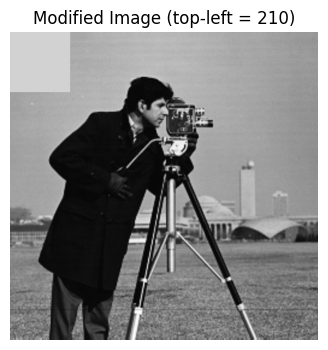

In [32]:

img_modified = img_arr.copy()
img_modified[:100, :100] = 210

plt.figure(figsize=(5,4))
plt.imshow(img_modified)
plt.title('Modified Image (top-left = 210)')
plt.axis('off')
plt.show()

## Exercise 2: Grayscale Image Processing (lena_gray.gif)

# Task 1: Load and display grayscale image

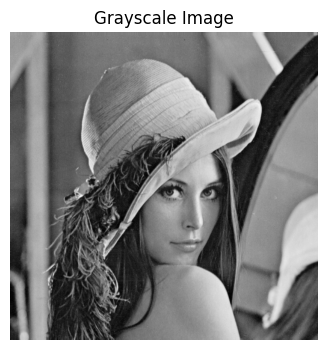

Shape: (512, 512)


In [33]:
gray_img = Image.open('/content/drive/MyDrive/lena.gif').convert('L')
gray_arr = np.array(gray_img)

plt.figure(figsize=(5,4))
plt.imshow(gray_arr, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()
print(f'Shape: {gray_arr.shape}')

# Task 2: Extract middle 150-pixel section

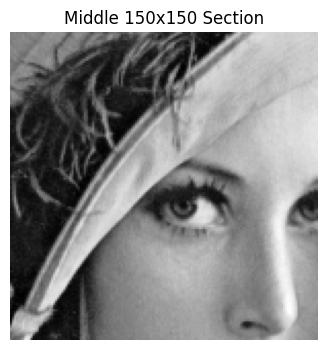

In [34]:
h, w = gray_arr.shape
cy, cx = h // 2, w // 2
middle = gray_arr[cy-75:cy+75, cx-75:cx+75]

plt.figure(figsize=(4,4))
plt.imshow(middle, cmap='gray')
plt.title('Middle 150x150 Section')
plt.axis('off')
plt.show()

# Task 3: Apply threshold (below 100 -> 0, above 100 -> 255)

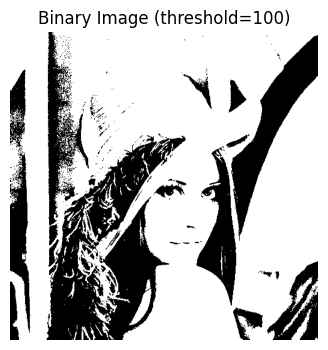

In [35]:
binary = np.where(gray_arr < 100, 0, 255).astype(np.uint8)

plt.figure(figsize=(5,4))
plt.imshow(binary, cmap='gray')
plt.title('Binary Image (threshold=100)')
plt.axis('off')
plt.show()

# Task 4: Rotate 90 degrees clockwise
# np.rot90 with k=-1 rotates clockwise


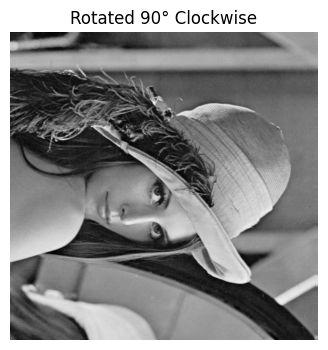

In [36]:
rotated = np.rot90(gray_arr, k=-1)

plt.figure(figsize=(5,4))
plt.imshow(rotated, cmap='gray')
plt.title('Rotated 90° Clockwise')
plt.axis('off')
plt.show()

# Task 5: Convert grayscale to RGB (replicate channel)

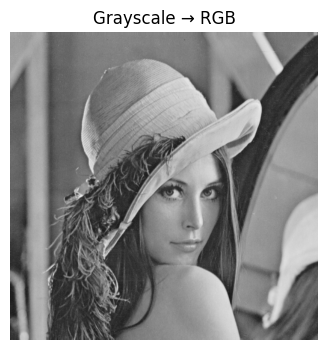

RGB shape: (512, 512, 3)


In [37]:
rgb_from_gray = np.stack([gray_arr, gray_arr, gray_arr], axis=2)

plt.figure(figsize=(5,4))
plt.imshow(rgb_from_gray)
plt.title('Grayscale → RGB')
plt.axis('off')
plt.show()
print(f'RGB shape: {rgb_from_gray.shape}')

## Exercise 3: PCA Image Compression from Scratch

# Load and prepare grayscale image for PCA

In [38]:
pca_img = Image.open('/content/drive/MyDrive/lena.gif').convert('L')
X = np.array(pca_img, dtype=np.float64)

print(f'Image shape: {X.shape}')


mean = np.mean(X, axis=1, keepdims=True)
X_centered = X - mean

print('Data centered.')

Image shape: (512, 512)
Data centered.


# Step 2: Covariance matrix

In [39]:
n = X_centered.shape[0]
cov_matrix = (X_centered.T @ X_centered) / (n - 1)
print(f'Covariance matrix shape: {cov_matrix.shape}')

Covariance matrix shape: (512, 512)


# Step 3: Eigen Decomposition


In [40]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)


idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f'Top 5 eigenvalues: {eigenvalues[:5]}')

Top 5 eigenvalues: [331703.83849056 196607.14475744 124416.21173953  79942.9823611
  67007.58850854]


# Step 4: Cumulative explained variance plot

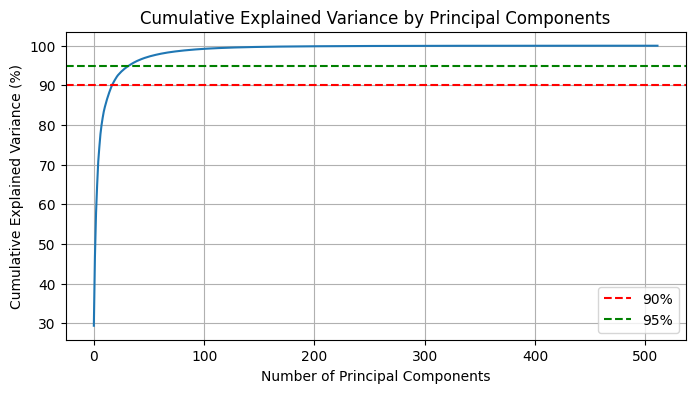

80% variance explained with k=8 components
90% variance explained with k=18 components
95% variance explained with k=33 components
99% variance explained with k=91 components


In [41]:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance * 100)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance by Principal Components')
plt.axhline(y=90, color='r', linestyle='--', label='90%')
plt.axhline(y=95, color='g', linestyle='--', label='95%')
plt.legend()
plt.grid(True)
plt.show()


for thresh in [0.80, 0.90, 0.95, 0.99]:
    k = np.argmax(cumulative_variance >= thresh) + 1
    print(f'{thresh*100:.0f}% variance explained with k={k} components')

# Step 5: Reconstruction function

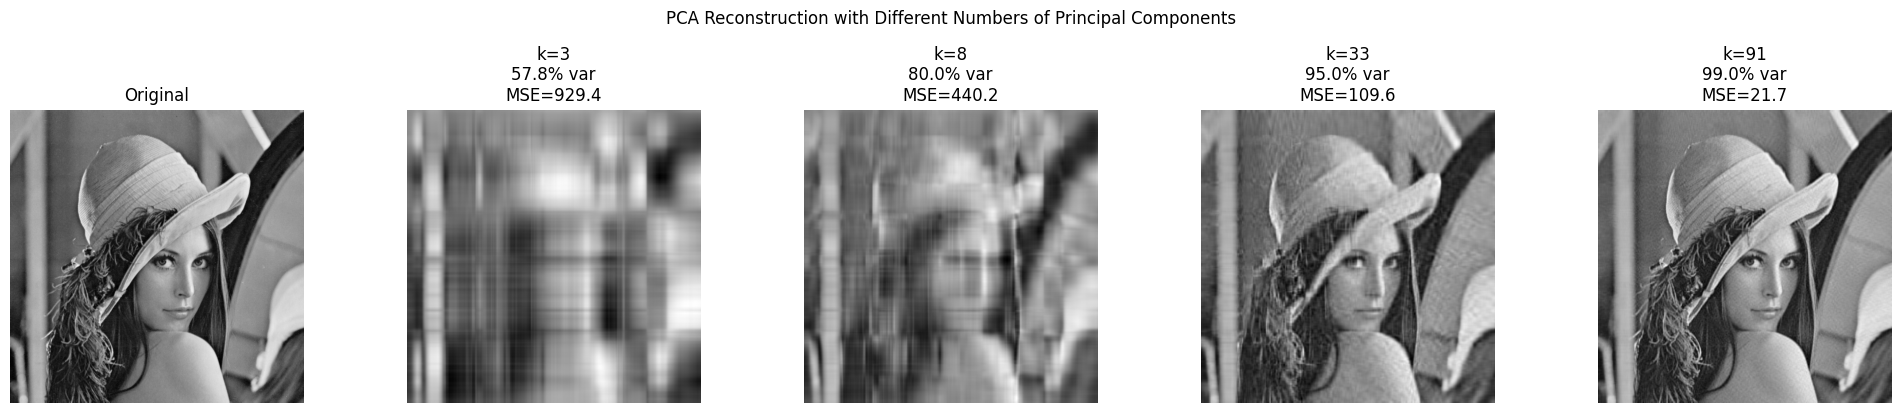


Summary:
k=   3: 57.8% variance, 99.4% size reduction
k=   8: 80.0% variance, 98.4% size reduction
k=  33: 95.0% variance, 93.6% size reduction
k=  91: 99.0% variance, 82.2% size reduction


In [42]:
def pca_reconstruct(X_centered, eigenvectors, mean, k):
    """Project to k PCs and reconstruct."""
    W = eigenvectors[:, :k]
    projected = X_centered @ W
    reconstructed = projected @ W.T
    return reconstructed + mean



k_values = [
    np.argmax(cumulative_variance >= 0.50) + 1,
    np.argmax(cumulative_variance >= 0.80) + 1,
    np.argmax(cumulative_variance >= 0.95) + 1,
    np.argmax(cumulative_variance >= 0.99) + 1,
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(X, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i, k in enumerate(k_values):
    recon = pca_reconstruct(X_centered, eigenvectors, mean, k)
    recon = np.clip(recon, 0, 255)
    ev = cumulative_variance[k-1] * 100


    mse = np.mean((X - recon) ** 2)

    axes[i+1].imshow(recon, cmap='gray')
    axes[i+1].set_title(f'k={k}\n{ev:.1f}% var\nMSE={mse:.1f}')
    axes[i+1].axis('off')

plt.suptitle('PCA Reconstruction with Different Numbers of Principal Components', y=1.02)
plt.tight_layout()
plt.show()

print('\nSummary:')
for k in k_values:
    ev = cumulative_variance[k-1] * 100
    compression = (1 - k / X.shape[1]) * 100
    print(f'k={k:4d}: {ev:.1f}% variance, {compression:.1f}% size reduction')